# **POSTPARTUM DEPRESSION: CLASSIFICATION**

**EFFORTS BY:**

*   VAISHNAVI UPADHYAY
      *   CSE-AI 3
      *   21201172024


*   TANISHA YADAV

     *   CSE-AI 3
     *   20401172024





In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/PPD_dataset_v2.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/PPD_dataset_v2.csv'

**DROP UNNECESSARY COLUMNS**

In [ ]:
df.drop(columns=["sr"], inplace=True)

**NUMBER OF ROWS AND COLUNMS**

In [ ]:
shape=df.shape
print("Rows:",shape[0])
print("Columns:",shape[1])

Rows: 800
Columns: 50


**CHECK FOR MISSING VALUES**

In [ ]:
df.isnull().sum()

,0
Age,0
Residence,0
Education Level,6
Marital status,0
Occupation before latest pregnancy,0
Monthly income before latest pregnancy,437
Occupation After Your Latest Childbirth,0
Current monthly income,525
Husband's education level,9
Husband’s monthly income,28


**CHEK IF DUPLCATE ROWS EXIST**

In [ ]:
  duplicate_rows=df.duplicated().sum()
  print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


**REMOVING DUPLICATE ROWS**

In [ ]:
df.drop_duplicates(inplace=True)

**GET ALL COLUMN NAMES**

In [ ]:
print(df.columns.tolist())

['Age', 'Residence', 'Education Level', 'Marital status', 'Occupation before latest pregnancy', 'Monthly income before latest pregnancy', 'Occupation After Your Latest Childbirth', 'Current monthly income', "Husband's education level", 'Husband’s monthly income', 'Addiction', 'Total children', 'Disease before pregnancy', 'History of pregnancy loss', 'Family type', 'Number of household members', 'Relationship with the in-laws', 'Relationship with husband', 'Relationship with the newborn', 'Relationship between father and newborn', 'Feeling about motherhood', 'Recieved Support', 'Need for Support', 'Major changes or losses during pregnancy', 'Abuse', 'Trust and share feelings', 'Number of the latest pregnancy', 'Pregnancy length', 'Pregnancy plan', 'Regular checkups', 'Fear of pregnancy', 'Diseases during pregnancy', 'Age of newborn', 'Age of immediate older children', 'Mode of delivery', 'Gender of newborn', 'Birth compliancy', 'Breastfeed', 'Newborn illness', 'Worry about newborn', 'Re

**FIX COLUMN NAMES**


*   **str.strip():** removes all the leading and trailing spaces in column names
*   **str.replace(' ', '_'):** replaces blank spaces with column names
***str.lower():** converts everything to lowercase



In [ ]:
df.columns=df.columns.str.strip().str.replace(' ', '_').str.lower()

**DEALING WITH NULL VALUES**

In [ ]:
#replacing null with 0, since null here indicates 0 income
income_cols=["monthly_income_before_latest_pregnancy", "current_monthly_income", "husband’s_monthly_income"]
df[income_cols]=df[income_cols].fillna(0)

#replacing null with no addiction, since null here indicates that there is no addiction
df["addiction"]=df["addiction"].fillna("No Addiction")

#replacing null with no disease, since null here indicates that there are no diseases
diseases=["disease_before_pregnancy", "diseases_during_pregnancy"]
df[diseases]=df[diseases].fillna("No Disease")

#replacing null with no miscarriage, since null here indicates that there are no miscarriages
df["history_of_pregnancy_loss"]=df["history_of_pregnancy_loss"].fillna("No Miscarriage")

In [ ]:
null_pct=df["age_of_immediate_older_children"].isna().mean()*100
print("Percentage of missing values:", null_pct)

Percentage of missing values: 64.625


In [ ]:
#dropping age_of_immediate_older_children column since it has many null values
df.drop("age_of_immediate_older_children", axis=1, inplace=True)

In [ ]:
#removing rows with null values of these columns, since there are not many null values to deal with
cols_to_drop_rows=["education_level", "husband's_education_level", "abuse", "trust_and_share_feelings"]
df.dropna(subset=cols_to_drop_rows, inplace=True)

In [ ]:
#replacing null values with mode of the respective columns
cols_to_replace_with_mode=["need_for_support", "feeling_for_regular_activities"]
for col in cols_to_replace_with_mode:
  df[col]=df[col].fillna(df[col].mode()[0])

**UNIQUE VALUES IN EACH COLUMN**

In [ ]:
for col in df.columns:
  print(col,":", df[col].unique())

age : [24 31 32 27 29 30 23 36 40 22 25 28 34 33 26 19 37 18 20 38 21 35 41 42
 45]
residence : ['City' 'Village']
education_level : ['University' 'College' 'Primary School' 'High School' 'High school'
 'Primary school']
marital_status : ['Married' 'Divorced']
occupation_before_latest_pregnancy : ['Student' 'Service' 'Doctor' 'Housewife' 'Teacher' 'Other' 'Business'
 'House wife']
monthly_income_before_latest_pregnancy : [0 '10000 to 20000' 'More than 30000' 'Less than 5000' '5000 to 10000'
 '20000 to 30000']
occupation_after_your_latest_childbirth : ['Student' 'Service' 'Doctor' 'Housewife' 'Teacher' 'Business' 'Other']
current_monthly_income : [0 '10000 to 20000' 'More than 30000' 'Less than 5000' '5000 to 10000'
 '20000 to 30000']
husband's_education_level : ['University' 'College' 'Primary School' 'High School' 'High school'
 'Primary school']
husband’s_monthly_income : ['More than 30000' '10000 to 20000' '5000 to 10000' '20000 to 30000' 0
 'Less than 5000']
addiction : ['No Addict

**FIXING INCONSISTENT CATEGORIES**

In [ ]:
df["education_level"]=df["education_level"].replace({
    "High school": "High School",
    "Primary school": "Primary School"
    })

df["husband's_education_level"]=df["husband's_education_level"].replace({
    "High school": "High School",
    "Primary school": "Primary School"
    })

df["occupation_before_latest_pregnancy"]=df["occupation_before_latest_pregnancy"].replace("House wife", "Housewife")

df=df[df["disease_before_pregnancy"]!="1.2"]

df["history_of_pregnancy_loss"]=df["history_of_pregnancy_loss"].replace({
    "Still-born Delivery":"Still-Born Delivery",
    "Still-born delivery":"Still-Born Delivery"
})

df["diseases_during_pregnancy"]=df["diseases_during_pregnancy"].replace({
    "Chronic disease":"Chronic Disease",
    "Non-chronic disease":"Non-Chronic Disease"

})

**DISTRIBUTION OF DEPRESSION SCREENING RESULTS**

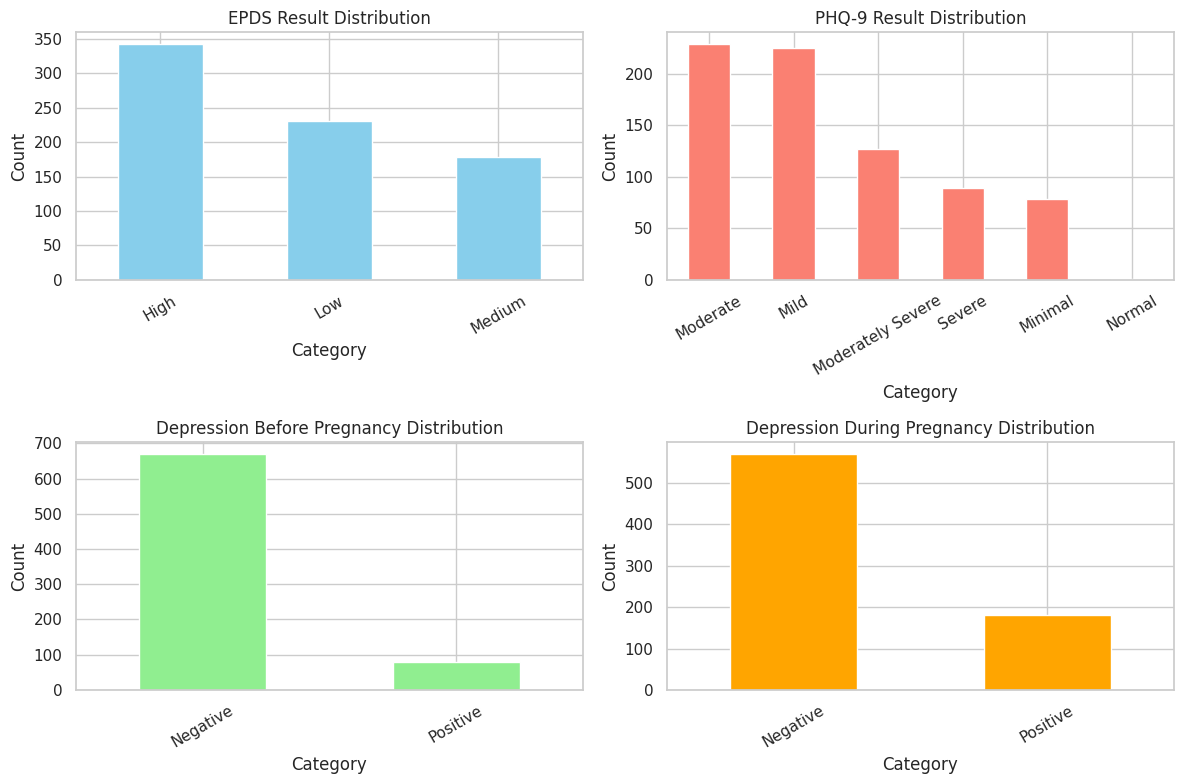

In [ ]:
import matplotlib.pyplot as plt

# Define features and colors
features = [
    ("epds_result", "EPDS Result Distribution"),
    ("phq9_result", "PHQ-9 Result Distribution"),
    ("depression_before_pregnancy_(phq2)", "Depression Before Pregnancy Distribution"),
    ("depression_during_pregnancy_(phq2)", "Depression During Pregnancy Distribution")
]

colors = ["skyblue", "salmon", "lightgreen", "orange"]

# Create subplots: 2 graphs per row
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# Flatten axes for easy iteration
axes = axes.flatten()

# Loop through features and plot
for i, (col, title) in enumerate(features):
    df[col].value_counts().plot(kind="bar", ax=axes[i], color=colors[i])
    axes[i].set_title(title)
    axes[i].set_xlabel("Category")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()



**EPDS RESULT VS SUPPORT RECEIVED**

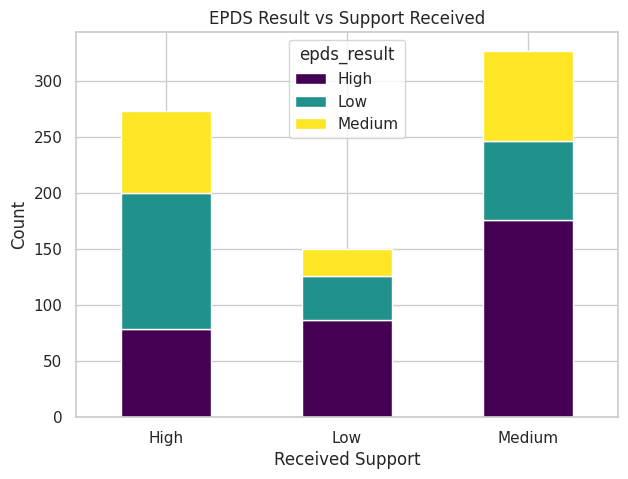

In [ ]:
pd.crosstab(df["recieved_support"], df["epds_result"]).plot(
    kind="bar", stacked=True, figsize=(7,5), colormap="viridis"
)
plt.title("EPDS Result vs Support Received")
plt.xlabel("Received Support")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

**PHQ-9 RESULTS VS MARITAL STATUS**

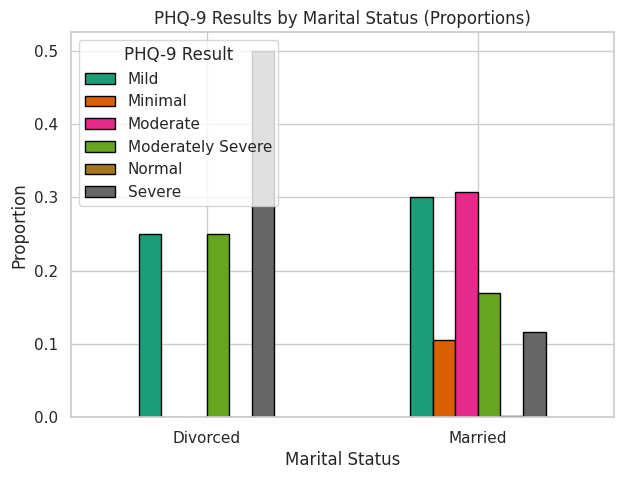

In [ ]:
# Reset style to light background
sns.set_style("whitegrid")

# Crosstab (already normalized by marital status)
marital_phq9 = pd.crosstab(df["marital_status"], df["phq9_result"], normalize="index")

marital_phq9.plot(
    kind="bar",
    figsize=(7,5),
    colormap="Dark2",
    edgecolor="black"
)

plt.title("PHQ-9 Results by Marital Status (Proportions)")
plt.ylabel("Proportion")
plt.xlabel("Marital Status")
plt.xticks(rotation=0)
plt.legend(title="PHQ-9 Result")
plt.show()

**EPDS RESULT VS EDUCATION LEVEL**

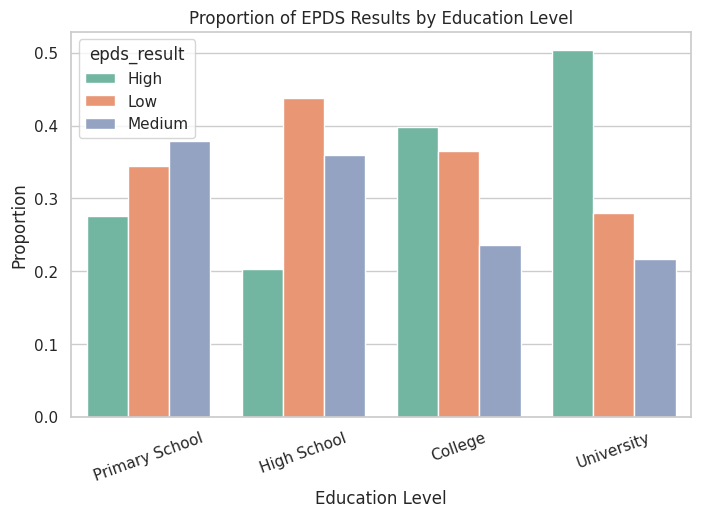

In [ ]:
edu_epds = (
    df.groupby("education_level")["epds_result"]
      .value_counts(normalize=True)
      .rename("proportion")
      .reset_index()
)

# --- Plot ---
plt.figure(figsize=(8,5))
sns.barplot(
    data=edu_epds,
    x="education_level",
    y="proportion",
    hue="epds_result",
    order=["Primary School", "High School", "College", "University"],
    palette="Set2"
)
plt.title("Proportion of EPDS Results by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Proportion")
plt.xticks(rotation=20)
plt.show()


**EPDS RESULT VS MARITAL STATUS**

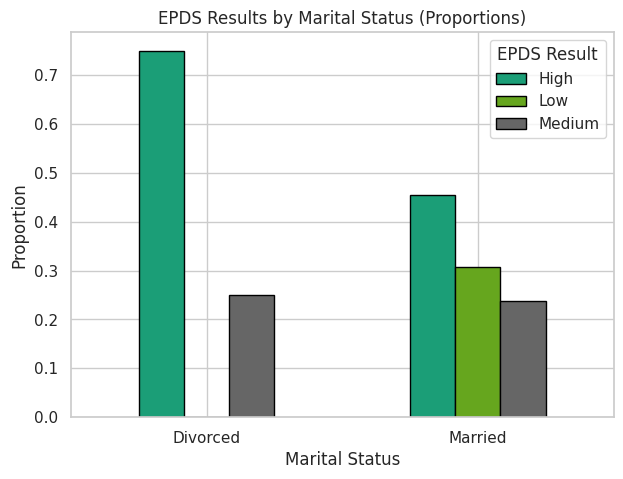

In [ ]:
# Crosstab for EPDS result (categorical)
marital_epds = pd.crosstab(df["marital_status"], df["epds_result"], normalize="index")

# Plot
marital_epds.plot(
    kind="bar",
    figsize=(7,5),
    colormap="Dark2",   # darker palette
    edgecolor="black"
)

plt.title("EPDS Results by Marital Status (Proportions)")
plt.ylabel("Proportion")
plt.xlabel("Marital Status")
plt.xticks(rotation=0)
plt.legend(title="EPDS Result")
plt.show()

**CONVERTING ORDINAL & CATEGORICAL VARIABLES INTO NUMERIC VALUES**

In [ ]:
# --- INCOME COLUMNS (convert ranges to midpoints) ---
income_mapping = {
    "Less than 5000": 2500,
    "5000 to 10000": 7500,
    "10000 to 20000": 15000,
    "20000 to 30000": 25000,
    "More than 30000": 35000,
    0: 0
}

In [ ]:
df["monthly_income_before_latest_pregnancy"] = df["monthly_income_before_latest_pregnancy"].replace(income_mapping)
df["current_monthly_income"] = df["current_monthly_income"].replace(income_mapping)
df["husband’s_monthly_income"] = df["husband’s_monthly_income"].replace(income_mapping)

/tmp/ipython-input-2448829178.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["monthly_income_before_latest_pregnancy"] = df["monthly_income_before_latest_pregnancy"].replace(income_mapping)
/tmp/ipython-input-2448829178.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["current_monthly_income"] = df["current_monthly_income"].replace(income_mapping)
/tmp/ipython-input-2448829178.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, expl

In [ ]:
# --- HOUSEHOLD MEMBERS (keep ordinal categories instead of fractional numbers) ---
household_mapping = {
    "2 to 5": 0,
    "6 to 8": 1,
    "9 or more": 2
}
df["number_of_household_members"] = df["number_of_household_members"].replace(household_mapping)

/tmp/ipython-input-2268189515.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["number_of_household_members"] = df["number_of_household_members"].replace(household_mapping)


In [ ]:
# --- PREGNANCY LENGTH (convert to months) ---
pregnancy_mapping = {
    "Less than 5 months": 4,
    "6 months": 6,
    "7 months": 7,
    "8 months": 8,
    "9 months": 9,
    "10 months": 10
}
df["pregnancy_length"] = df["pregnancy_length"].replace(pregnancy_mapping)

/tmp/ipython-input-1546011431.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["pregnancy_length"] = df["pregnancy_length"].replace(pregnancy_mapping)


In [ ]:
# --- AGE OF NEWBORN (convert to approx. months) ---
newborn_mapping = {
    "0 to 6 months": 3,
    "6 months to 1 year": 9,
    "1 year to 1.5 year": 15,
    "Older than 1.5 year": 18
}
df["age_of_newborn"] = df["age_of_newborn"].replace(newborn_mapping)

/tmp/ipython-input-441210499.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["age_of_newborn"] = df["age_of_newborn"].replace(newborn_mapping)


In [ ]:
# --- TOTAL CHILDREN (convert to numeric) ---
children_mapping = {
    "One": 1,
    "Two": 2,
    "More than two": 3,
    "More than Two":3
}
df["total_children"] = df["total_children"].replace(children_mapping)


/tmp/ipython-input-3425252427.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["total_children"] = df["total_children"].replace(children_mapping)


In [ ]:
# --- RELATIONSHIP VARIABLES ---
relationship_mapping = {
    "Bad": 1,
    "Poor": 2,
    "Neutral": 3,
    "Good": 4,
    "Friendly": 5,
    "Very good": 6   # only for newborn-related columns
}

df["relationship_with_the_in-laws"] = df["relationship_with_the_in-laws"].replace(relationship_mapping).infer_objects(copy=False)
df["relationship_with_husband"] = df["relationship_with_husband"].replace(relationship_mapping).infer_objects(copy=False)
df["relationship_with_the_newborn"] = df["relationship_with_the_newborn"].replace(relationship_mapping).infer_objects(copy=False)
df["relationship_between_father_and_newborn"] = df["relationship_between_father_and_newborn"].replace(relationship_mapping).infer_objects(copy=False)

/tmp/ipython-input-638506413.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["relationship_with_the_in-laws"] = df["relationship_with_the_in-laws"].replace(relationship_mapping).infer_objects(copy=False)
/tmp/ipython-input-638506413.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["relationship_with_husband"] = df["relationship_with_husband"].replace(relationship_mapping).infer_objects(copy=False)
/tmp/ipython-input-638506413.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed i

In [ ]:
# --- FEELING ABOUT MOTHERHOOD ---
motherhood_mapping = {
    "Sad": 1,
    "Neutral": 2,
    "Happy": 3
}
df["feeling_about_motherhood"] = df["feeling_about_motherhood"].replace(motherhood_mapping).astype(int)

/tmp/ipython-input-1046683334.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["feeling_about_motherhood"] = df["feeling_about_motherhood"].replace(motherhood_mapping).astype(int)


In [ ]:
# --- PHQ9 RESULT (depression severity scale) ---
phq9_mapping = {
    "Normal": 0,
    "Minimal": 1,
    "Mild": 2,
    "Moderate": 3,
    "Moderately Severe": 4,
    "Severe": 5
}
df["phq9_result"] = df["phq9_result"].replace(phq9_mapping).astype(int)

/tmp/ipython-input-2032948947.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["phq9_result"] = df["phq9_result"].replace(phq9_mapping).astype(int)


In [ ]:
# --- PHQ2 Depression (Before & During Pregnancy) ---
phq2_mapping = {
    "Negative": 0,
    "Positive": 1
}

df["depression_before_pregnancy_(phq2)"] = df["depression_before_pregnancy_(phq2)"].replace(phq2_mapping).astype(int)
df["depression_during_pregnancy_(phq2)"] = df["depression_during_pregnancy_(phq2)"].replace(phq2_mapping).astype(int)

/tmp/ipython-input-4125605194.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["depression_before_pregnancy_(phq2)"] = df["depression_before_pregnancy_(phq2)"].replace(phq2_mapping).astype(int)
/tmp/ipython-input-4125605194.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["depression_during_pregnancy_(phq2)"] = df["depression_during_pregnancy_(phq2)"].replace(phq2_mapping).astype(int)


In [ ]:
# --- BINARY ENCODING (convert Yes/No responses to 1/0) ---
df=df.replace({
    "Yes":1,
    "No":0
})

/tmp/ipython-input-157148613.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df=df.replace({


In [ ]:
# --- ORDINAL ENCODING (convert Low/Medium/High to numeric scale) ---
df=df.replace({
    "Low":1,
    "Medium":2,
    "High":3
})

/tmp/ipython-input-3302763724.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df=df.replace({


**ONE HOT ENCODING**

In [ ]:
categorical_cols=df.select_dtypes("object").columns
categorical_cols

Index(['residence', 'education_level', 'marital_status',
       'occupation_before_latest_pregnancy',
       'occupation_after_your_latest_childbirth', 'husband's_education_level',
       'addiction', 'disease_before_pregnancy', 'history_of_pregnancy_loss',
       'family_type', 'diseases_during_pregnancy', 'mode_of_delivery',
       'gender_of_newborn', 'feeling_for_regular_activities'],
      dtype='object')

In [ ]:
df=pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

**SCALING**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
continous_cols_to_scale = [
    "age", "monthly_income_before_latest_pregnancy", "current_monthly_income",
    "husband’s_monthly_income", "total_children", "number_of_household_members",
    "number_of_the_latest_pregnancy", "pregnancy_length", "age_of_newborn",
    "phq9_score", "epds_score"
]
df[continous_cols_to_scale]=scaler.fit_transform(df[continous_cols_to_scale])

In [ ]:
ordinal_cols_to_scale = [
    "total_children",
    "number_of_household_members",
    "phq9_result",
    "age_of_newborn",
    "pregnancy_length",
    "number_of_the_latest_pregnancy"
]
df[ordinal_cols_to_scale]=scaler.fit_transform(df[ordinal_cols_to_scale])

**CORRELATION MATRIX**

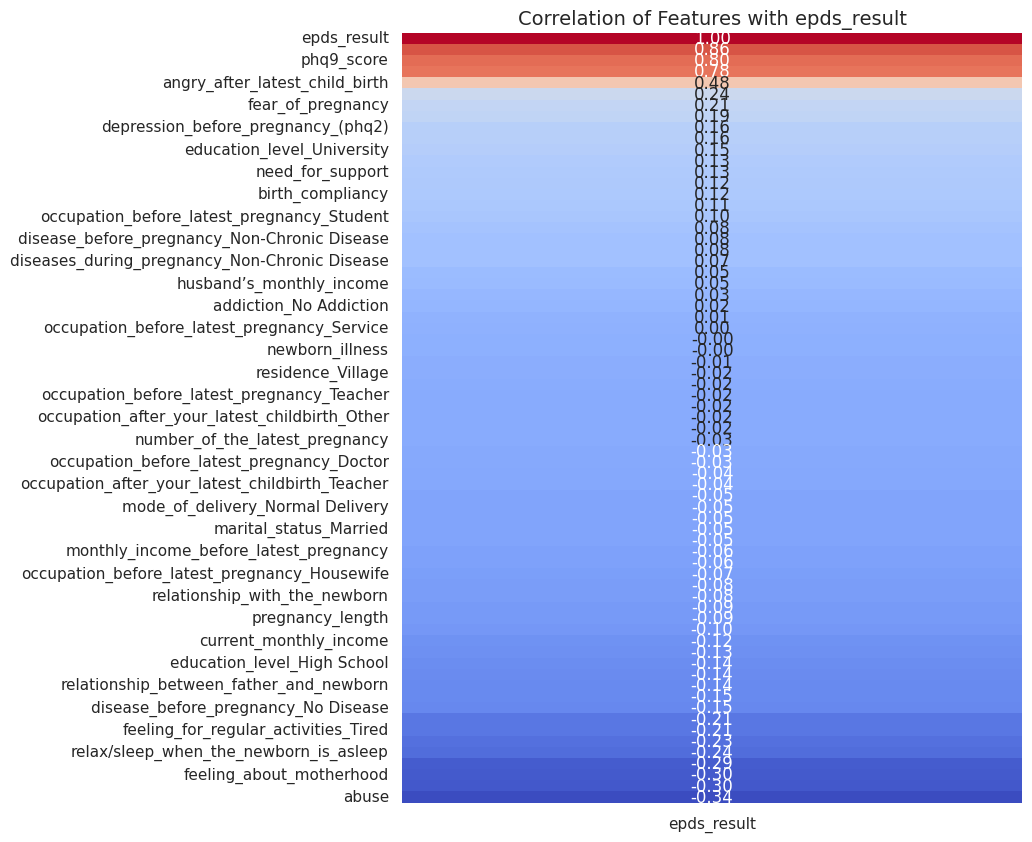

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Correlation of features with target ---
target = "epds_result"

corr_with_target = df.corr()[target].sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.heatmap(corr_with_target.to_frame(), annot=True, cmap="coolwarm", fmt=".2f", cbar=False)
plt.title(f"Correlation of Features with {target}", fontsize=14)
plt.show()



**SPLIT FEATURES AND TARGET**

*   **Target Feature:** epds_result







In [ ]:
X=df.drop('epds_result', axis=1);
y=df['epds_result']

**TRAIN TEST SPLIT**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

**LOGISTIC REGRESSION**

In [ ]:
from sklearn.linear_model import LogisticRegression

model_lr=LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
train_score_lr=model_lr.score(X_train, y_train)
test_score_lr=model_lr.score(X_test, y_test)

print("Train Score:", train_score_lr)
print("Test Score:", test_score_lr)

Train Score: 0.9828571428571429
Test Score: 0.8888888888888888


In [ ]:
from sklearn.metrics import classification_report
y_pred=model_lr.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.95      0.87      0.91        69
           2       0.77      0.75      0.76        53
           3       0.91      0.97      0.94       103

    accuracy                           0.89       225
   macro avg       0.88      0.87      0.87       225
weighted avg       0.89      0.89      0.89       225



**DECISION TREE**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_dt=DecisionTreeClassifier()
model_dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
train_score_dt=model_dt.score(X_train, y_train)
test_score_dt=model_dt.score(X_test, y_test)

print("Train Score:", train_score_dt)
print("Test Score:", test_score_dt)

Train Score: 1.0
Test Score: 0.9422222222222222


In [ ]:
from sklearn.metrics import classification_report
y_pred=model_dt.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.97      0.91      0.94        69
           2       0.88      0.87      0.88        53
           3       0.95      1.00      0.98       103

    accuracy                           0.94       225
   macro avg       0.94      0.93      0.93       225
weighted avg       0.94      0.94      0.94       225



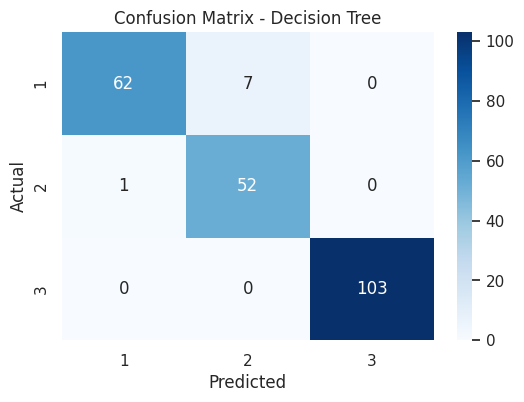

In [ ]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model_dt.classes_,
            yticklabels=model_dt.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


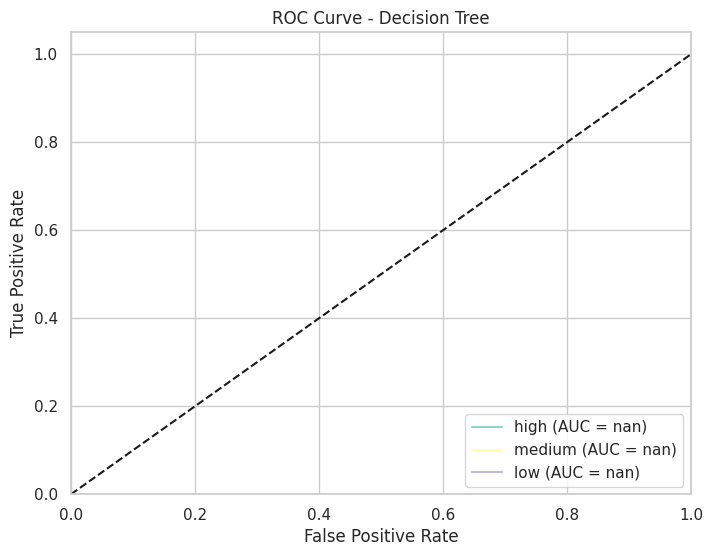

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Assuming y_test contains the true labels and model_dt is your trained Decision Tree
# Binarize the target
classes = ['high', 'medium', 'low']
y_test_bin = label_binarize(y_test, classes=classes)

# Get predicted probabilities for each class
y_score = model_dt.predict_proba(X_test)

# Plot ROC curves for each class
plt.figure(figsize=(8,6))

for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc='lower right')
plt.show()


**RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf=RandomForestClassifier()
model_rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
train_score_rf=model_rf.score(X_train, y_train)
test_score_rf=model_rf.score(X_test, y_test)

print("Train Score:", train_score_rf)
print("Test Score:", test_score_rf)

Train Score: 1.0
Test Score: 0.9466666666666667


In [ ]:
from sklearn.metrics import classification_report
y_pred=model_rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.97      0.90      0.93        69
           2       0.86      0.92      0.89        53
           3       0.98      0.99      0.99       103

    accuracy                           0.95       225
   macro avg       0.94      0.94      0.94       225
weighted avg       0.95      0.95      0.95       225



**XGBOOST**

In [ ]:
from xgboost import XGBClassifier

# Initialize XGBoost classifier
model_xgb = XGBClassifier(num_class=3, objective="multi:softprob", random_state=42)

# Train with adjusted labels (0,1,2)
y_train_adj = y_train - 1
y_test_adj = y_test - 1

model_xgb.fit(X_train, y_train_adj)

# Predictions
y_pred_adj = model_xgb.predict(X_test)

# Convert back to 1,2,3
y_pred = y_pred_adj + 1

In [ ]:
train_score_xgb=model_xgb.score(X_train, y_train_adj)
test_score_xgb=model_xgb.score(X_test, y_test_adj)

print("Train Score:", train_score_xgb)
print("Test Score:", test_score_xgb)

Train Score: 1.0
Test Score: 0.9688888888888889


In [ ]:
from sklearn.metrics import classification_report

# Predictions (adjust back to original labels 1,2,3)
y_pred_adj = model_xgb.predict(X_test)
y_pred = y_pred_adj + 1

# Classification report with numeric target names
print(classification_report(y_test, y_pred, zero_division=0, target_names=["1", "2", "3"]))

              precision    recall  f1-score   support

           1       0.98      0.91      0.95        69
           2       0.90      0.98      0.94        53
           3       1.00      1.00      1.00       103

    accuracy                           0.97       225
   macro avg       0.96      0.96      0.96       225
weighted avg       0.97      0.97      0.97       225



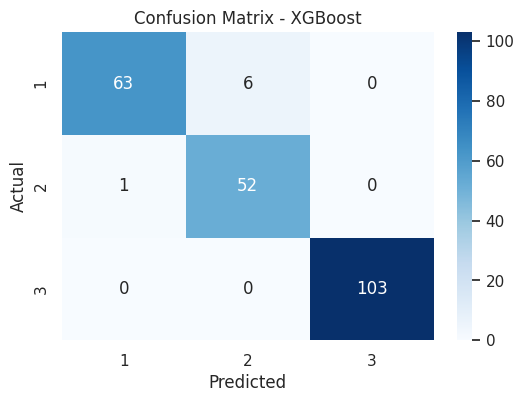

In [ ]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix (use adjusted labels)
cm = confusion_matrix(y_test - 1, y_pred_adj)

# Heatmap with class labels as 1, 2, 3
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["1", "2", "3"],
            yticklabels=["1", "2", "3"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

**KNN CLASSIFIER**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
train_score_knn=model_knn.score(X_train, y_train)
test_score_knn=model_knn.score(X_test, y_test)

print("Train Score:", train_score_knn)
print("Test Score:", test_score_knn)

Train Score: 0.8285714285714286
Test Score: 0.7288888888888889


In [ ]:
from sklearn.metrics import classification_report
y_pred=model_knn.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.71      0.83      0.77        69
           2       0.48      0.43      0.46        53
           3       0.87      0.82      0.84       103

    accuracy                           0.73       225
   macro avg       0.69      0.69      0.69       225
weighted avg       0.73      0.73      0.73       225



**SVC**

In [ ]:
from sklearn.svm import SVC
model_svc= SVC()
model_svc.fit(X_train, y_train)

SVC()

In [ ]:
train_score_svc=model_svc.score(X_train, y_train)
test_score_svc=model_svc.score(X_test, y_test)

print("Train Score:", train_score_svc)
print("Test Score:", test_score_svc)

Train Score: 0.8971428571428571
Test Score: 0.8222222222222222


In [ ]:
from sklearn.metrics import classification_report
y_pred=model_svc.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.89      0.84      0.87        69
           2       0.65      0.58      0.61        53
           3       0.86      0.93      0.89       103

    accuracy                           0.82       225
   macro avg       0.80      0.79      0.79       225
weighted avg       0.82      0.82      0.82       225



**GRID SEARCH CV: LOGISTIC REGRESSION**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'penalty': ['l2', None],
    'solver': ['lbfgs', 'saga'],
    'C': [0.1, 1, 10]
}

grid_search_lr = GridSearchCV(
    estimator=model_lr,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

grid_search_lr.fit(X_train, y_train)

print("Best Parameters:", grid_search_lr.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


Best Parameters: {'C': 0.1, 'penalty': None, 'solver': 'saga'}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
final_lr = grid_search_lr.best_estimator_
final_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=0.1, max_iter=1000, penalty=None, random_state=42,
                   solver='saga')

In [ ]:
train_score = final_lr.score(X_train, y_train)
test_score = final_lr.score(X_test, y_test)

print("Train Score:", train_score)
print("Test Score:", test_score)

Train Score: 1.0
Test Score: 0.9111111111111111


In [ ]:
from sklearn.metrics import classification_report
y_pred=final_lr.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.95      0.87      0.91        69
           2       0.80      0.83      0.81        53
           3       0.94      0.98      0.96       103

    accuracy                           0.91       225
   macro avg       0.90      0.89      0.90       225
weighted avg       0.91      0.91      0.91       225



**GRID SEARCH CV: RANDOM FOREST**

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', None]
}


grid_search = GridSearchCV(
    estimator=model_rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation R2 Score:", grid_search.best_score_)
final_rf = grid_search.best_estimator_

Best Parameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation R2 Score: 0.9847619047619048


In [ ]:
train_score_final_rf= final_rf.score(X_train, y_train)
test_score_final_rf = final_rf.score(X_test, y_test)

print("Train Score:", train_score_final_rf)
print("Test Score:", test_score_final_rf)

Train Score: 0.9904761904761905
Test Score: 0.9644444444444444


In [ ]:
from sklearn.metrics import classification_report
y_pred=final_rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.98      0.90      0.94        69
           2       0.88      0.98      0.93        53
           3       1.00      1.00      1.00       103

    accuracy                           0.96       225
   macro avg       0.96      0.96      0.96       225
weighted avg       0.97      0.96      0.96       225



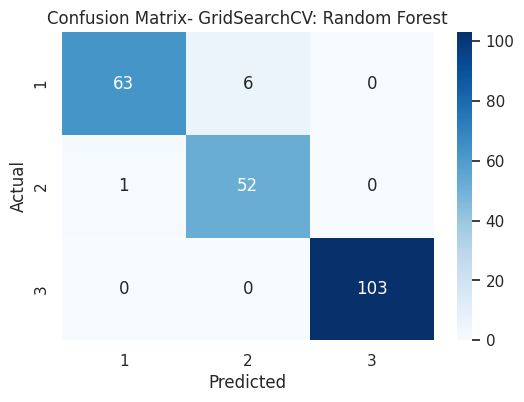

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=final_rf.classes_,
            yticklabels=final_rf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix- GridSearchCV: Random Forest")
plt.show()

In [ ]:
results = {
    "Linear Regression": [train_score_lr, test_score_lr],
    "Decision Tree": [train_score_dt, test_score_dt],
    "Random Forest": [train_score_rf, test_score_rf],
    "XGBoost": [train_score_xgb, test_score_xgb],
    "KNN":[train_score_knn, test_score_knn],
    "SVC":[train_score_svc, test_score_svc],
    "GridSearchCv: Linear Regression": [train_score, test_score],
    "GridSearchCv: Random Forest": [train_score_final_rf, test_score_final_rf]
}


# Convert to DataFrame
scores_df = pd.DataFrame(results, index=["Train Score", "Test Score"])

scores_df

,Linear Regression,Decision Tree,Random Forest,XGBoost,KNN,SVC,GridSearchCv: Linear Regression,GridSearchCv: Random Forest
Train Score,0.982857,1.000000,1.000000,1.000000,0.828571,0.897143,1.000000,0.990476
Test Score,0.888889,0.942222,0.946667,0.968889,0.728889,0.822222,0.911111,0.964444


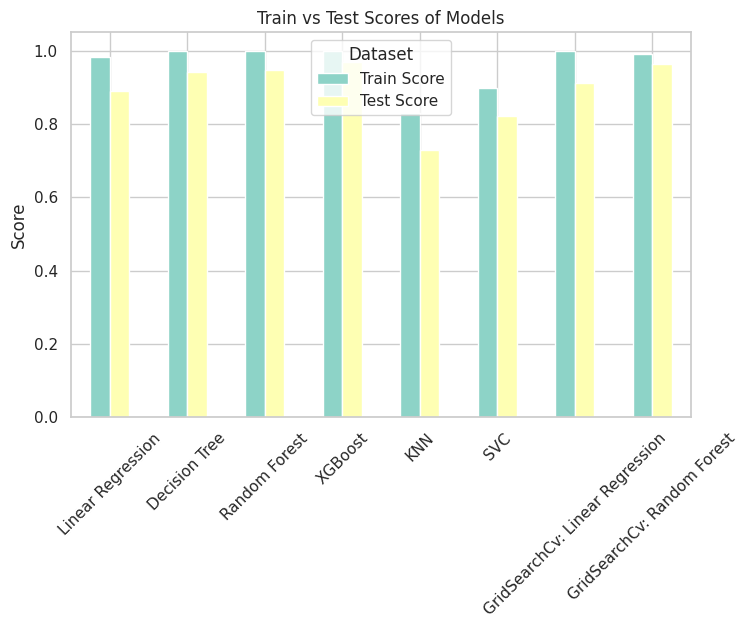

In [ ]:
import matplotlib.pyplot as plt

scores_df.T.plot(kind="bar", figsize=(8,5))
plt.title("Train vs Test Scores of Models")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(title="Dataset")
plt.show()

In [ ]:
best_model=model_xgb